# 03. Soft-PINN Penalty Gradient Collision

A soft physics-informed neural network keeps the same unconstrained output head, then adds a physics penalty to the training objective. In scalar form, the optimizer sees something like `$L = L_data + lambda * L_physics$`, where `L_data` is usually MSE and `L_physics` penalizes monotonicity violations or Coulomb-counting disagreement.

That is not a safety guarantee. It is a tradeoff. When the data gradient and physics gradient point in different directions, the optimizer compromises. Increasing `lambda` can reduce violations, but it can also damage data fit or stall training. Decreasing `lambda` preserves fit but lets violations through. This is the gradient-collision pathology: the physical invariant is negotiated by loss weighting instead of enforced by architecture.

For functional safety, compromise is failure. A BMS cannot certify a model that violates discharge monotonicity 17 percent of the time and call it safe because the violation rate is lower than a vanilla baseline. ISO 26262-style safety argument needs invariants or bounded failure modes, not average-case penalty pressure.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'logs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and logs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})

print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load Sprint 44 soft-PINN ledger

The historical `PI-TCN` row is the soft-constraint baseline. It reduced PVR in Scenario A relative to vanilla LSTM and TCN, but it did not reach zero. In Scenario B it remained catastrophically high. This is exactly the failure expected from a penalty method: lower violation pressure, no invariant.


In [2]:
log_path = ROOT / 'logs' / 'sprint44_results_v3.json'
if not log_path.exists():
    raise FileNotFoundError(log_path)

ledger = json.loads(log_path.read_text(encoding='utf-8'))
results = pd.DataFrame(ledger['results'])
for col in ['rmse_pct', 'mae_pct', 'max_error_pct', 'pvr']:
    results[col] = results[col].astype(float)
results['Scenario'] = results['scenario'].str.replace('_', ' ', regex=False)
results['Model family'] = results['model'].map({'LSTM': 'Vanilla LSTM', 'TCN': 'Vanilla TCN', 'PI-TCN': 'Soft-PINN PI-TCN'})
table = results[['Scenario', 'Model family', 'rmse_pct', 'max_error_pct', 'pvr', 'n_violations', 'n_discharge']].copy()
table = table.rename(columns={
    'rmse_pct': 'RMSE (%)',
    'max_error_pct': 'MaxE (%)',
    'pvr': 'PVR (%)',
    'n_violations': 'Violations',
    'n_discharge': 'Discharge steps',
})
display(table.round({'RMSE (%)': 3, 'MaxE (%)': 3, 'PVR (%)': 3}))

pi = table[table['Model family'] == 'Soft-PINN PI-TCN']
assert np.isclose(float(pi[pi['Scenario'] == 'Scenario A']['PVR (%)'].iloc[0]), 17.021099614858258), 'Unexpected Scenario A PI-TCN PVR.'
assert np.isclose(float(pi[pi['Scenario'] == 'Scenario B']['PVR (%)'].iloc[0]), 43.62624254473161), 'Unexpected Scenario B PI-TCN PVR.'


,Scenario,Model family,RMSE (%),MaxE (%),PVR (%),Violations,Discharge steps
0,Scenario A,Vanilla LSTM,12.571,81.743,50.484,1851089,3666702
1,Scenario A,Vanilla TCN,49.843,94.352,22.117,810968,3666702
2,Scenario A,Soft-PINN PI-TCN,40.992,89.556,17.021,624113,3666702
3,Scenario B,Vanilla LSTM,6.186,52.747,45.185,323874,716775
4,Scenario B,Vanilla TCN,5.483,55.858,50.546,362304,716775
5,Scenario B,Soft-PINN PI-TCN,6.788,54.949,43.626,312702,716775


## Penalty reduces violations; it does not certify zero

The red dashed line is the only safety target that matters: zero PVR. Anything above it is a physical impossibility observed in the prediction stream.


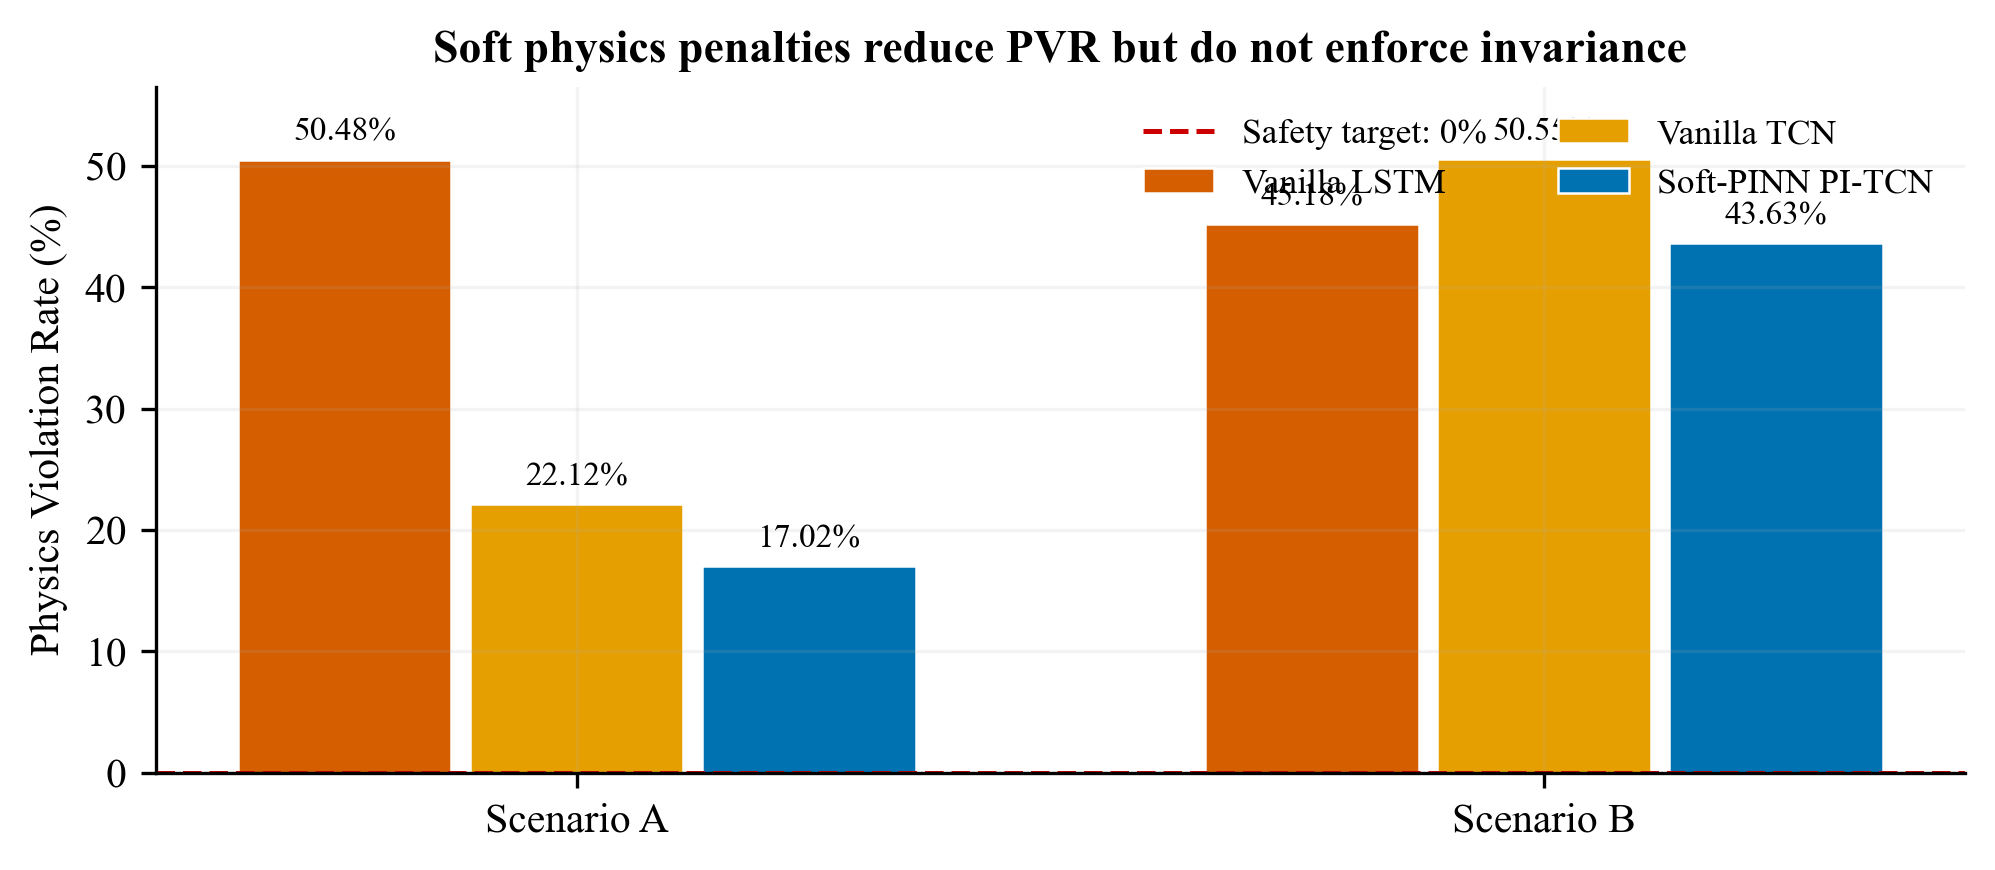

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_03_soft_pinn_gradient_collision.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_03_soft_pinn_gradient_collision.png


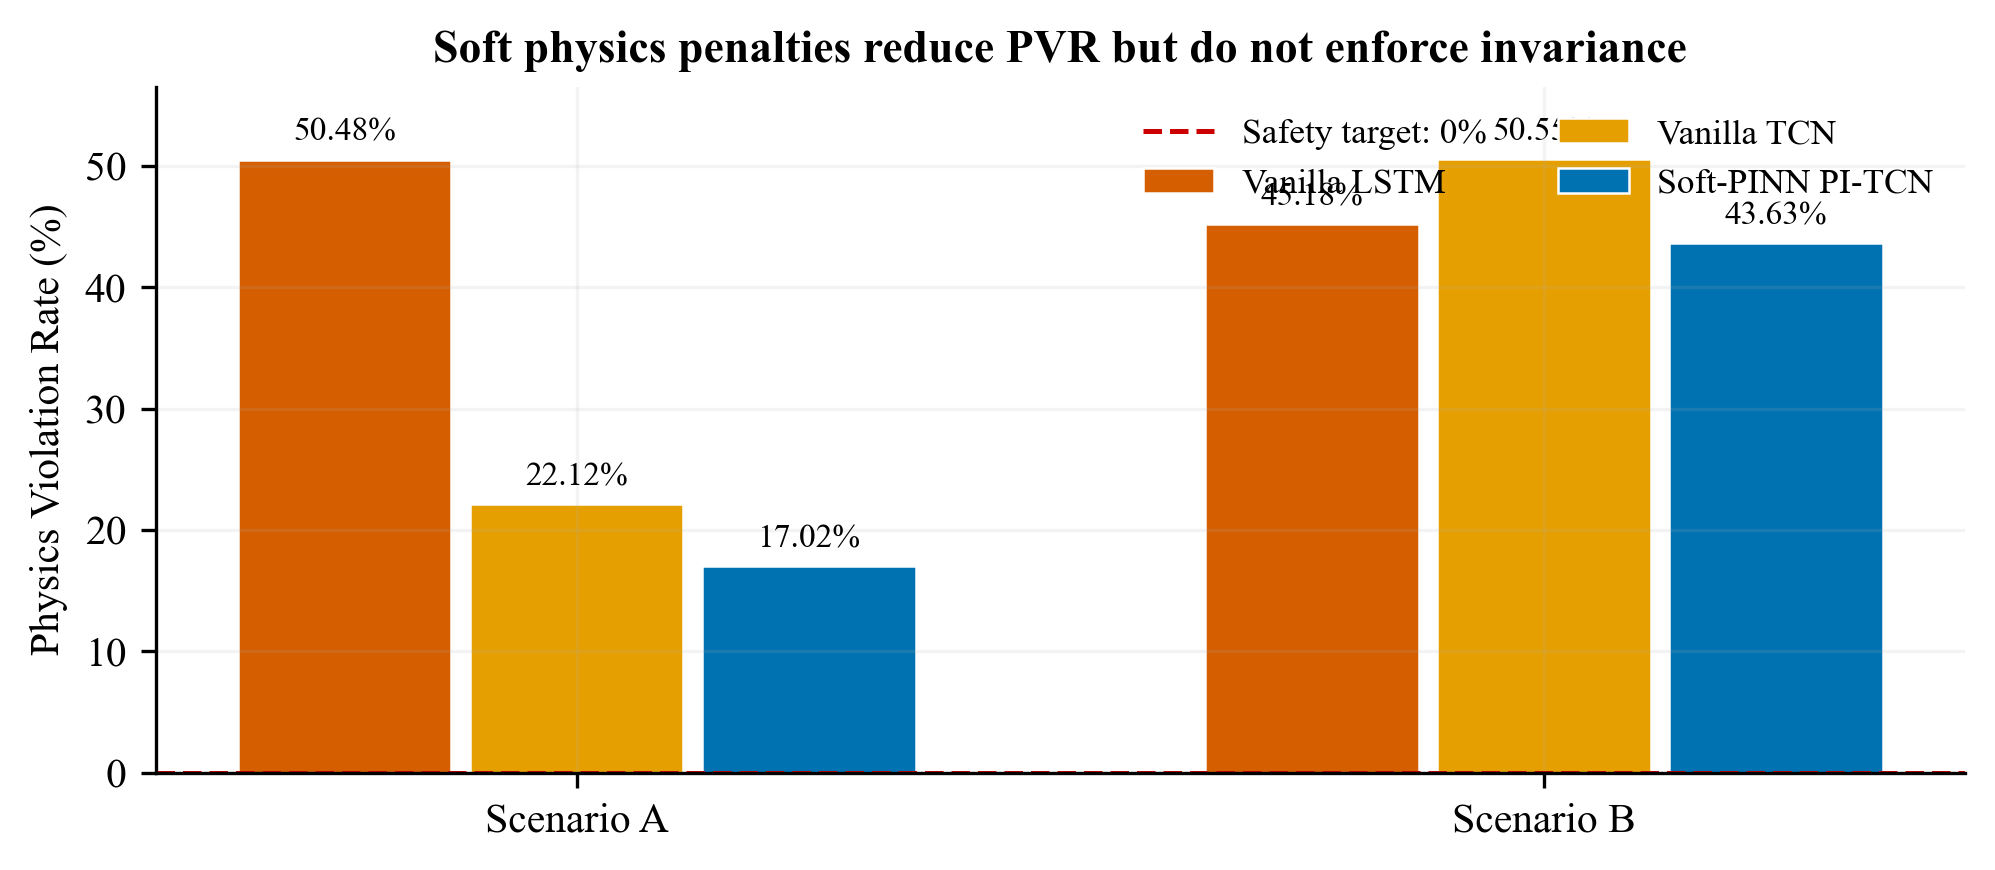

In [3]:
plot_df = table.copy()
scenarios = ['Scenario A', 'Scenario B']
models = ['Vanilla LSTM', 'Vanilla TCN', 'Soft-PINN PI-TCN']
colors = {'Vanilla LSTM': '#D55E00', 'Vanilla TCN': '#E69F00', 'Soft-PINN PI-TCN': '#0072B2'}

fig, ax = plt.subplots(figsize=(6.75, 3.0))
x = np.arange(len(scenarios))
width = 0.24
for i, model in enumerate(models):
    values = [float(plot_df[(plot_df['Scenario'] == s) & (plot_df['Model family'] == model)]['PVR (%)'].iloc[0]) for s in scenarios]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width=width * 0.92, color=colors[model], edgecolor='white', linewidth=0.6, label=model)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(0, color='#CC0000', linestyle='--', linewidth=1.2, label='Safety target: 0%')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Physics Violation Rate (%)')
ax.set_ylim(0, max(56.0, plot_df['PVR (%)'].max() + 6.0))
ax.set_title('Soft physics penalties reduce PVR but do not enforce invariance')
ax.legend(loc='upper right', ncol=2)
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_03_soft_pinn_gradient_collision.pdf'
png_path = FIG_DIR / 'fig_03_soft_pinn_gradient_collision.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

Soft-PINN failed because it tried to buy safety with a scalar penalty weight. That weight cannot convert an unconstrained regressor into a certified monotone system. The physics residual can be reduced, but if the output head can still emit arbitrary adjacent SOC values, PVR remains an empirical metric rather than an invariant.
